# Simple Curve Fitting in Python

In previous lectures, we learned how to visualize data using `matplotlib` and `pandas`, and how to perform numerical computations with `numpy`. A natural next step is to ask: **can we find a mathematical model that describes the relationship between variables in our data?**

Curve fitting is the process of constructing a mathematical function that passes through (or near) a set of data points. This is one of the fundamental techniques in data analysis and has applications across science, engineering, and business:

We will build understanding progressively, starting with the simplest case and building up to more complex models.

In the following, we will make some use of basic notions of linear algebra, such as

- matrix multiplication 
- matrix transpose
- matrix inverse. 

This means that we will be working with matrices and vectors, which in `numpy` are easily represented as 2D and 1D arrays, respectively.

Consider refreshing these concepts (see for example these comprehensive [notes](https://bookdown.org/rachaelmcarey/lanotes/matrices.html)). 

## Solving a system of linear equations

Fitting data fundamentally involves finding the numerical values of parameters that describe the mathematical model between the variables in our data. 

Before actually fitting data, let us try and solve a simpler problem: suppose we simply have a pair of unknowns, `x` and `y`, and we have two equations that relate them:

$$
\begin{aligned}
2x + 3y &= 5 \\
4x - y &= 3
\end{aligned}
$$

This is a system of linear equations, and we can solve it using various methods such as substitution, elimination, or matrix operations.

The matrix representation is the most convenient when the purpose is to develop a numerical scheme.

The matrix form of the above system is:


$$ 
A \vec{p} = \vec{b}
$$


Where:

- $A$ is the coefficient matrix:
$$
A = \begin{bmatrix}
2 & 3 \\
4 & -3
\end{bmatrix}
$$
- $\vec{p}$ is the vector of unknowns:
$$
\vec{p} = \begin{bmatrix}x \\
y
\end{bmatrix}
$$
- $\vec{b}$ is the constant vector:
$$
\vec{b} = \begin{bmatrix}5 \\
3
\end{bmatrix}
$$ 

We normally solve this by substitution and eliminination, leading to the solution $x = 1$ and $y = 1$.

The algebraic, matrix formulation is easily interpreted by the computer wich uses well established matrix transformation techniques (e.g. [LU decomposition](https://en.wikipedia.org/wiki/LU_decomposition)) to solve for the unknowns.

In `numpy`, this is implemented in the `numpy.linalg.solve` function, which efficiently solves the system of linear equations.

In [5]:

import numpy as np

A = np.array([[2,3], [4,-1]]) # constructing the matrix A
b = np.array([5, 3]) # constructing the vector b

solution = np.linalg.solve(A, b) # solving the system of equations Ap = b

solution

array([1., 1.])

## Constructing a linear model with data

Now, let's imagine that we have a dataset of $N$ points that we want to fit a line to. Let's call them $x_i=\{x_1, x_2, \dots, x_N\}$ and $y_i=\{y_1, y_2, \dots, y_N\}$.

These could be, for example, measurements of the height of a particle at different times, or the price of a stock at different days.

The idea is that there is an underlying relationhsip between $x_i$ and $y_i$ but that the data is noisy for various reasons (e.g. measurement errors, natural variability, etc.).

This means that we are thinking of the data as being generated by a model of the form:

$$
y_i = m x_i + b + \epsilon_i
$$

where $m$ is the slope of the line, $b$ is the intercept, and $\epsilon_i$ is the error term that captures the noise in the data.

What we want to find the **best values** of $m$ and $b$ that describe the relationship between $x_i$ and $y_i$ in a purely linear model.

We can rewrite this linear model in matrix form as:

$$\boxed{\vec{y} = X \vec{\theta}}$$

where 

$$ \vec{y} = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_N \end{bmatrix} $$

$$  X = \begin{bmatrix} x_1 & 1 \\ x_2 & 1 \\ \vdots & \vdots \\ x_N & 1 \end{bmatrix} $$

and 

$$ \vec{\theta} = \begin{bmatrix} m \\ b \end{bmatrix}$$


What we want to do is therefore to find the values of $\vec{\theta}$ that minimize the distance between the predicted values $X \vec{\theta}$ and the actual values $\vec{y}$, which is equivalent to finding the values of $m$ and $b$ that minimize the sum of squared errors:

$$
\text{SSE} = \sum_{i=1}^N (y_i - (m x_i + b))^2
$$

It turns out that this problem can be worked analytically by taking the derivative of the SSE with respect to $m$ and $b$, setting it to zero, and solving for $m$ and $b$. This leads to the so-called **normal equations** for the determination of the parameters:

$$
\vec{\theta} = (X^T X)^{-1} X^T \vec{y}
$$

where $X^T$ stands for the transpose of the matrix $X$ and $(X^T X)^{-1}$ is the inverse of the matrix $X^T X$. This method is called **ordinary least squares** and is the most common method for fitting linear models to data.

The normal equations can be re-written as:

$$
X^T X \theta = X^T \vec{y}
$$

This is simply a system of linear equations in the form $A \vec{p} = \vec{b}$, where $A = X^T X$, $\vec{p} = \theta$, and $\vec{b} = X^T \vec{y}$. 

We know how to solve this from the previous section, and this is exactly what `numpy.linalg.solve` does when we call it with $A$ and $\vec{b}$.



We can see in example in actin in `numpy` by using artificial data. In the `numpy` implementation notice that we make use of a few handy tools:

- `np.ones_like(x)` creates an array of ones with the same shape as `x`, which we use to create the intercept term in our design matrix.
- `np.column_stack((x, np.ones_like(x)))` stacks the `x` array and the intercept array column-wise to create the design matrix `X`.
- `np.linalg.solve`
- the operator `@` whhich performs matrix multiplication in a more readable way than `np.dot` or `np.matmul`.

In [12]:
import numpy as np

rng = np.random.default_rng(seed=42) # setting a random seed for reproducibility

# generate artificial data for chosen values of m and b
m_true = 2.5
b_true = 1.0
N = 1000 # change this to increase/decrease the number of data points
x = np.linspace(0, 10, N) # N evenly spaced points between 0 and 10
y = m_true * x + b_true + rng.normal(0, 1, size=x.shape) # adding some noise to the data

# now construct the matrix X and vector y for the linear model
X = np.column_stack((x, np.ones_like(x))) # adding a column of ones for the intercept

# solve for theta using the normal equations
theta = np.linalg.solve(X.T @ X, X.T @ y)
m_est, b_est = theta
print(f"Estimated slope: {m_est}, Estimated intercept: {b_est}")


Estimated slope: 2.499999160389713, Estimated intercept: 0.9711126470554914


## Beyond linear models: polynomial fitting

The machinery that we have constructed for fitting with straight lines can be easily extended to fit more complex models, such as polynomials.

This is thanks to teh following observation: take, for example, a quadratic model:

$$
y_i = a x_i^2 + b x_i + c 
$$

Now we have an extra parameter, $a$, that captures the curvature of the data. However, we can again rewrite the entire model in matrix form by expanding the matrix $X$ to include the new term:

$$
X = \begin{bmatrix} x_1^2 & x_1 & 1 \\
 x_2^2 & x_2 & 1 \\
 \vdots & \vdots & \vdots \\
 x_N^2 & x_N & 1 \end{bmatrix}
$$

and then the parameter vector becomes:
$$
\vec{\theta} = \begin{bmatrix} a \\ b \\ c \end{bmatrix}
$$

so that again the model can be written as 

$$\vec{y} = X \vec{\theta}$$

This means that  the solution is given by the **same normal equations** as before!

Let's see this in action again with `numpy` and some artificial data.

In [23]:
N = 100 # change this to increase/decrease the number of data points
x = np.linspace(0, 10, N)
# generate artificial data for chosen values of a, b, and c
a_true = 0.5
b_true = 1.0
c_true = -0.3

y = a_true * x**2 + b_true * x + c_true + rng.normal(0, 1, size=x.shape) # adding some noise to the data
# construct the matrix X for the quadratic model
X = np.column_stack((x**2, x, np.ones_like(x))) # three columns for x^2, x, and the intercept

theta = np.linalg.solve(X.T @ X, X.T @ y)
a_est, b_est, c_est = theta
print(f"Estimated a: {a_est}, Estimated b: {b_est}, Estimated c: {c_est}")

Estimated a: 0.49270657786412486, Estimated b: 1.0184643154717736, Estimated c: -0.10810882262020237


To plot the data it is important to note that the fitted curve needs to be evaluated typically at many more pints that the original $x_i$ data, so that it looks smooth.

Text(0.5, 1.0, 'Quadratic Fit to Data')

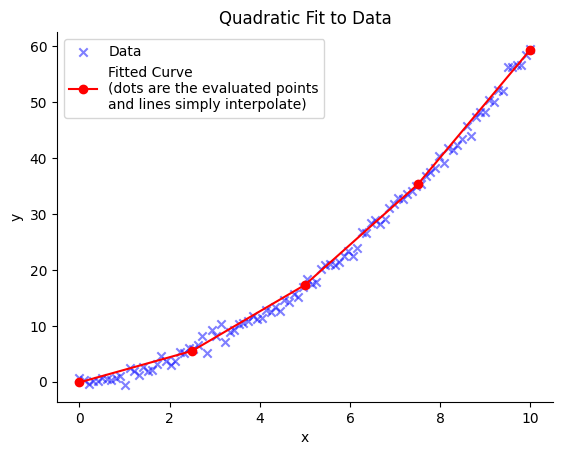

In [36]:
import matplotlib.pyplot as plt

# plotting the data and the fitted curve
plt.scatter(x, y, label='Data', color='blue', alpha=0.5, marker="x")
n_points_fitted_curve = 5 # try increasing this to see a smoother curve
x_fit = np.linspace(0, 10, n_points_fitted_curve) 
y_fit = a_est * x_fit**2 + b_est * x_fit + c_est
plt.plot(x_fit, y_fit,'-o', label='Fitted Curve \n(dots are the evaluated points\nand lines simply interpolate)', color='red')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Quadratic Fit to Data')

## Practical Implementation: NumPy's `polyfit`

Rather than implementing the matrix math ourselves every time, numpy provides the `polyfit` function, which fits a polynomial of specified degree to data. For linear regression, we use degree 1.

The syntax is straigthtforward:

```python
coefficients = np.polyfit(x, y, degree)
```

returns the coefficients of the polynomial.

In [38]:
coeffs = np.polyfit(x, y, 2) # fitting a quadratic polynomial to the data
a_polyfit, b_polyfit, c_polyfit = coeffs
print(f"Estimated a (polyfit): {a_polyfit}, Estimated b (polyfit): {b_polyfit}, Estimated c (polyfit): {c_polyfit}")  
print(f"Difference in a: {a_est - a_polyfit}, Difference in b: {b_est - b_polyfit}, Difference in c: {c_est - c_polyfit}") # notice that the difference is essentially numerical noise

Estimated a (polyfit): 0.4927065778641188, Estimated b (polyfit): 1.0184643154718283, Estimated c (polyfit): -0.10810882262027377
Difference in a: 6.050715484207103e-15, Difference in b: -5.46229728115577e-14, Difference in c: 7.140121827120538e-14


## Errors on the fitting parameters

The fitting parameters we obtain are estimates under specific assumptions:

- that the data has a random scatter (typically thought as due to normally distributed errors)
- that such errors have constant variance across all observation  and zero mean
- that the various observations are not correlated with each other

The resulting estimates are associated with an uncertainty which can be quantified.

We can use the Sum of Squared Errors to construct a benchmark:

$$\sigma^2 = \dfrac{SSE}{N-p}$$

where $N$ is the number of data points and $p$ is the number of parameters in the model (e.g. $p=2$ for a linear model).

We can then use this to obatin **covariance matrix** of the parameters, which is given by:

$$\text{Cov}(\vec{\theta}) = \sigma^2 (X^T X)^{-1}$$

where $X$ is the design matrix we constructed for the fitting. This is a $p \times p$ matrix that contains the variances of the parameters on the diagonal and the covariances between parameters on the off-diagonal.

The expression above can be thought as a ratio between the performance of the fit (as measured by $\sigma^2$) and the mutual independence of the parameters (as measured by the inverse of $X^T X$): the least clustered are the data points in the $x$ space, the more independent are the parameters and the smaller is the covariance matrix. Conversely, if the data points are clustered together, the parameters become more correlated and the covariance matrix becomes larger.


In numpy we can obtain the covariance matrix of the parameters by using the `cov` argument of the `polyfit` function:


In [39]:
coeffs, cov = np.polyfit(x, y, 2, cov=True) # fitting a quadratic polynomial to the data

cov

array([[ 0.00013045, -0.00130448,  0.00215218],
       [-0.00130448,  0.0139318 , -0.02595659],
       [ 0.00215218, -0.02595659,  0.06522195]])

In [40]:
# the diagonal of the covariance matrix gives us the variance of the estimated coefficients
var_a, var_b, var_c = np.diag(cov)
print(f"Variance of a: {var_a}, Variance of b: {var_b}, Variance of c: {var_c}")

Variance of a: 0.00013044842890267677, Variance of b: 0.013931801700804792, Variance of c: 0.06522195135317277


In [41]:
# the errors are then the square root of the variances
error_a = np.sqrt(var_a)
error_b = np.sqrt(var_b)
error_c = np.sqrt(var_c)
print("Estimate a with error: ", a_polyfit, "+/-", error_a)
print("Estimate b with error: ", b_polyfit, "+/-", error_b)
print("Estimate c with error: ", c_polyfit, "+/-", error_c) 

Estimate a with error:  0.4927065778641188 +/- 0.011421402230141304
Estimate b with error:  1.0184643154718283 +/- 0.11803305342489785
Estimate c with error:  -0.10810882262027377 +/- 0.2553858871456541


In practice, estimating the fitting parameters with their errors directly from the covariance matrix tends to underestimate true errors, for example when the model is not certain or when the data is not well-behaved. 

A conceptually simply and robust approach is to recur to resampling: this method is called **bootstrap**.




### Errors from bootstrapping

Instead of computing the covariance matrix, we can augment our dataset by resampling it with replacement, and then fitting the model to each resampled dataset.

The variability of the estimates yields immediately a variance of the parameters, which can be used to quantify the uncertainty of the estimates.

The procedure goes as follows:

- we resample the data to produce a series of the **same size** as the original dataset, but with replacement (i.e. some data points may be repeated and some may be left out).
- we fit the model to each bootstrap sample to obtain a distribution of parameter estimates.
- we compute the standard deviation of the parameter estimates across the bootstrap samples to obtain an estimate of the uncertainty of the parameters.

The tuneable parameter is the number of bootstrap samples, which typically is in the range of 1000-10000.

In [45]:
## bootstrap method for error estimation
n_bootstrap = 1000
bootstrap_estimates = np.zeros((n_bootstrap, 3)) # to store the estimates
for i in range(n_bootstrap):
    # picking random indices for resampling
    indices = rng.choice(N, size=N, replace=True) # resampling with replacement

    x_bootstrap = x[indices]
    y_bootstrap = y[indices]
    # fitting the model to the resampled data
    coeffs_bootstrap = np.polyfit(x_bootstrap, y_bootstrap, 2)
    bootstrap_estimates[i] = coeffs_bootstrap


a_bootstrap_estimates = bootstrap_estimates[:, 0]
b_bootstrap_estimates = bootstrap_estimates[:, 1]
c_bootstrap_estimates = bootstrap_estimates[:, 2]   
print(f"Bootstrap estimate of a: {np.mean(a_bootstrap_estimates)} with error {np.std(a_bootstrap_estimates)}")
print(f"Bootstrap estimate of b: {np.mean(b_bootstrap_estimates)} with error {np.std(b_bootstrap_estimates)}")
print(f"Bootstrap estimate of c: {np.mean(c_bootstrap_estimates)} with error {np.std(c_bootstrap_estimates)}")  

Bootstrap estimate of a: 0.4924942554971251 with error 0.011245170640561067
Bootstrap estimate of b: 1.0188262670084725 with error 0.10681213080081353
Bootstrap estimate of c: -0.10636872417879464 with error 0.21164197467522175


Reassuringly, the errors are compatible with the ones obtained from the covariance matrix, but they are more robust to violations of the assumptions of the model and to outliers in the data.